# Bước 2b — Mở Rộng Độc Lập: Dense Retrieval (SBERT) & Hybrid Search Đối Sánh
## Module 7.2b: So Sánh Toàn Diện 3 Chiến Lược IR (BM25 vs SBERT vs Hybrid BM25+SBERT)

---

### Bối cảnh & Động lực Học thuật:
Trong bài báo gốc *ViFactCheck (arXiv:2412.15308)*, nhóm tác giả đã chỉ ra rằng:
1. **BM25 (Sparse Retrieval):** Bị giới hạn bởi hiện tượng *Lexical Mismatch* — không thể truy xuất các câu dùng từ đồng nghĩa hoặc diễn đạt gián tiếp.
2. **SBERT (Dense Semantic Retrieval):** Biểu diễn ngữ nghĩa dưới dạng vector 768 chiều, giúp bắt trúng các câu đồng nghĩa nhưng có thể thiếu nhạy bén với số liệu và tên riêng chính xác.
3. **Hybrid Search (BM25 + SBERT):** Kết hợp cả hai để tận dụng ưu điểm kép (từ khóa chính xác + hiểu sâu ngữ nghĩa).

### Mục tiêu của Notebook này:
- **Giữ nguyên hiện trạng** của `02_bm25_retrieval.ipynb` làm nhánh chuẩn (Baseline).
- Xây dựng **nhánh mở rộng đối chứng** tại Bước 2 sử dụng mô hình SBERT tiếng Việt chuẩn: `bkai-foundation-models/vietnamese-bi-encoder`.
- Đo đạc chính xác: **Recall@1, Recall@3, Recall@5, Recall@10 và MRR** trên 500 mẫu Non-NEI tập Dev.
- Xuất file kết quả Top-10 ứng viên cho mỗi Claim để làm đầu vào cho tầng tiếp theo (Fact-aware Reranking & BamiBERT).

In [1]:
import os
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from rank_bm25 import BM25Okapi
from transformers import AutoModel, AutoTokenizer

PROJECT_ROOT = Path("../..").resolve()
DEV_PATH = PROJECT_ROOT / "data/processed/common_cleaned/vifactcheck_dev_common_cleaned.csv"
CAND_PATH = PROJECT_ROOT / "data/processed/retrieval/evidence_candidates.csv"
OUTPUT_DIR = PROJECT_ROOT / "data/processed/retrieval"
METRICS_DIR = PROJECT_ROOT / "notebooks/IR_IE_Reranking/outputs"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"✓ Thiết bị tính toán: {device}")

df_dev = pd.read_csv(DEV_PATH)
df_candidates = pd.read_csv(CAND_PATH)
print(f"✓ Nạp thành công {len(df_dev):,} claims và {len(df_candidates):,} câu ứng viên.")

✓ Thiết bị tính toán: mps
✓ Nạp thành công 723 claims và 12,823 câu ứng viên.


In [2]:
MODEL_ID = "bkai-foundation-models/vietnamese-bi-encoder"
print(f"Đang nạp mô hình SBERT: {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
sbert_model = AutoModel.from_pretrained(MODEL_ID).to(device)
sbert_model.eval()

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

def encode_batch(texts, batch_size=128):
    all_embs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            b_texts = texts[i : i + batch_size]
            encoded = tokenizer(b_texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
            out = sbert_model(**encoded)
            emb = mean_pooling(out, encoded["attention_mask"])
            emb = F.normalize(emb, p=2, dim=1)
            all_embs.append(emb.cpu())
    return torch.cat(all_embs, dim=0)

print("✓ Bộ mã hóa vector ngữ nghĩa SBERT đã sẵn sàng!")

Đang nạp mô hình SBERT: bkai-foundation-models/vietnamese-bi-encoder...


/opt/anaconda3/lib/python3.13/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


✓ Bộ mã hóa vector ngữ nghĩa SBERT đã sẵn sàng!


In [3]:
t0 = time.time()
print("Đang mã hóa toàn bộ 12,823 câu ứng viên sang vector 768 chiều...")
cand_embeddings = encode_batch(df_candidates["sentence_text"].fillna("").tolist(), batch_size=128)

print("Đang mã hóa 723 câu Tuyên bố (Claims)...")
claim_embeddings = encode_batch([str(s) for s in df_dev["Statement"]], batch_size=128)
print(f"✓ Hoàn tất mã hóa toàn bộ tập dữ liệu trong: {time.time() - t0:.2f} giây.")

Đang mã hóa toàn bộ 12,823 câu ứng viên sang vector 768 chiều...


Đang mã hóa 723 câu Tuyên bố (Claims)...


✓ Hoàn tất mã hóa toàn bộ tập dữ liệu trong: 134.27 giây.


In [4]:
def normalize_evidence_text(t: str) -> str:
    return re.sub(r"\s+", " ", str(t).lower()).strip()

def is_evidence_match(candidate: str, gold_evidence: str, min_overlap: float = 0.6) -> bool:
    if not isinstance(gold_evidence, str) or not gold_evidence.strip():
        return False
    cand_norm = normalize_evidence_text(candidate)
    gold_norm = normalize_evidence_text(gold_evidence)
    if cand_norm in gold_norm or gold_norm in cand_norm:
        return True
    c_words = set(cand_norm.split())
    g_words = set(gold_norm.split())
    if not c_words or not g_words:
        return False
    return len(c_words.intersection(g_words)) / min(len(c_words), len(g_words)) >= min_overlap

cand_group = df_candidates.groupby("claim_id").indices
eval_claims = df_dev[df_dev["labels"] != 2].copy()

bm25_ranks, sbert_ranks, hybrid_ranks = [], [], []

for idx, row in eval_claims.iterrows():
    claim_id = f"dev_{row['index']}"
    gold_text = str(row["Evidence"]) if pd.notna(row["Evidence"]) else ""
    if claim_id not in cand_group:
        continue
        
    cand_indices = cand_group[claim_id]
    cands = df_candidates.iloc[cand_indices]["sentence_text"].tolist()
    if not cands:
        continue
        
    # 1. SBERT
    c_emb = claim_embeddings[idx]
    sub_cand_embs = cand_embeddings[cand_indices]
    sbert_sims = torch.mv(sub_cand_embs, c_emb).numpy()
    
    # 2. BM25
    tok_corpus = [re.findall(r"\b\w+\b", doc.lower()) for doc in cands]
    bm25 = BM25Okapi(tok_corpus)
    tok_query = re.findall(r"\b\w+\b", str(row["Statement"]).lower())
    bm25_scores = np.array(bm25.get_scores(tok_query))
    
    # 3. Hybrid (Normalized Sum)
    b_max = bm25_scores.max() if bm25_scores.max() > 0 else 1.0
    bm25_norm = bm25_scores / b_max
    s_min, s_max = sbert_sims.min(), sbert_sims.max()
    sbert_norm = (sbert_sims - s_min) / (s_max - s_min + 1e-6)
    hybrid_scores = 0.5 * bm25_norm + 0.5 * sbert_norm
    
    def get_hit_rank(scores):
        for r, c_i in enumerate(np.argsort(scores)[::-1], 1):
            if is_evidence_match(cands[c_i], gold_text):
                return r
        return 999
        
    bm25_ranks.append(get_hit_rank(bm25_scores))
    sbert_ranks.append(get_hit_rank(sbert_sims))
    hybrid_ranks.append(get_hit_rank(hybrid_scores))

def calc_ir_metrics(ranks):
    ranks = np.array(ranks)
    n = len(ranks)
    return {
        "Recall@1 (%)": round(float(np.mean(ranks == 1) * 100), 2),
        "Recall@3 (%)": round(float(np.mean(ranks <= 3) * 100), 2),
        "Recall@5 (%)": round(float(np.mean(ranks <= 5) * 100), 2),
        "Recall@10 (%)": round(float(np.mean(ranks <= 10) * 100), 2),
        "MRR": round(float(np.sum(1.0 / np.where(ranks < 999, ranks, np.inf)) / n), 4)
    }

df_metrics = pd.DataFrame([
    {"Phương pháp": "BM25 (Okapi) [Baseline]", **calc_ir_metrics(bm25_ranks)},
    {"Phương pháp": "SBERT (Vietnamese Bi-Encoder)", **calc_ir_metrics(sbert_ranks)},
    {"Phương pháp": "Hybrid (BM25 + SBERT)", **calc_ir_metrics(hybrid_ranks)}
])

print("\n" + "=" * 75)
print("BẢNG ĐỐI SÁNH HIỆU NĂNG TẦNG TRUY XUẤT (FIRST-STAGE IR - TẬP DEV):")
print("=" * 75)
print(df_metrics.to_string(index=False))
print("=" * 75)

# Lưu file kết quả metrics
df_metrics.to_csv(METRICS_DIR / "08_stage1_ir_comparison.csv", index=False)


BẢNG ĐỐI SÁNH HIỆU NĂNG TẦNG TRUY XUẤT (FIRST-STAGE IR - TẬP DEV):
                  Phương pháp  Recall@1 (%)  Recall@3 (%)  Recall@5 (%)  Recall@10 (%)    MRR
      BM25 (Okapi) [Baseline]          89.8          96.4          97.0           99.2 0.9328
SBERT (Vietnamese Bi-Encoder)          82.2          93.0          96.2           98.4 0.8814
        Hybrid (BM25 + SBERT)          90.0          95.6          97.2           99.0 0.9323


In [5]:
# Xuất Top 10 câu ứng viên tốt nhất của Hybrid Search phục vụ Fact Reranking
top10_rows = []
TOP_K_RETRIEVAL = 10

for idx, row in df_dev.iterrows():
    claim_id = f"dev_{row['index']}"
    claim_text = str(row['Statement'])
    gold_text = str(row['Evidence']) if pd.notna(row['Evidence']) else ''
    
    if claim_id not in cand_group:
        continue
    cand_indices = cand_group[claim_id]
    cands = df_candidates.iloc[cand_indices]['sentence_text'].tolist()
    if not cands:
        continue
        
    c_emb = claim_embeddings[idx]
    sub_cand_embs = cand_embeddings[cand_indices]
    sbert_sims = torch.mv(sub_cand_embs, c_emb).numpy()
    
    tok_corpus = [re.findall(r"\b\w+\b", doc.lower()) for doc in cands]
    bm25 = BM25Okapi(tok_corpus)
    tok_query = re.findall(r"\b\w+\b", claim_text.lower())
    bm25_scores = np.array(bm25.get_scores(tok_query))
    
    b_max = bm25_scores.max() if bm25_scores.max() > 0 else 1.0
    bm25_norm = bm25_scores / b_max
    s_min, s_max = sbert_sims.min(), sbert_sims.max()
    sbert_norm = (sbert_sims - s_min) / (s_max - s_min + 1e-6)
    hybrid_scores = 0.5 * bm25_norm + 0.5 * sbert_norm
    
    top_indices = np.argsort(hybrid_scores)[::-1][:TOP_K_RETRIEVAL]
    for rank, c_i in enumerate(top_indices, 1):
        cand_sent = cands[c_i]
        is_hit = is_evidence_match(cand_sent, gold_text) if row['labels'] != 2 else False
        top10_rows.append({
            'claim_id': claim_id,
            'claim_index': row['index'],
            'claim': claim_text,
            'retrieved_evidence': cand_sent,
            'bm25_score': round(float(bm25_scores[c_i]), 4),
            'sbert_sim': round(float(sbert_sims[c_i]), 4),
            'hybrid_score': round(float(hybrid_scores[c_i]), 4),
            'retrieval_rank': rank,
            'is_gold': is_hit,
            'label': row['labels'],
            'gold_evidence': gold_text if row['labels'] != 2 else ''
        })

df_top10 = pd.DataFrame(top10_rows)
out_top10_path = OUTPUT_DIR / 'hybrid_top10_results.csv'
df_top10.to_csv(out_top10_path, index=False)
print(f"✓ Đã xuất Top-10 ứng viên ({len(df_top10):,} dòng) tại: {out_top10_path.name}")

✓ Đã xuất Top-10 ứng viên (6,884 dòng) tại: hybrid_top10_results.csv


✓ Đã lưu biểu đồ đối sánh tại: 08_stage1_ir_comparison.png


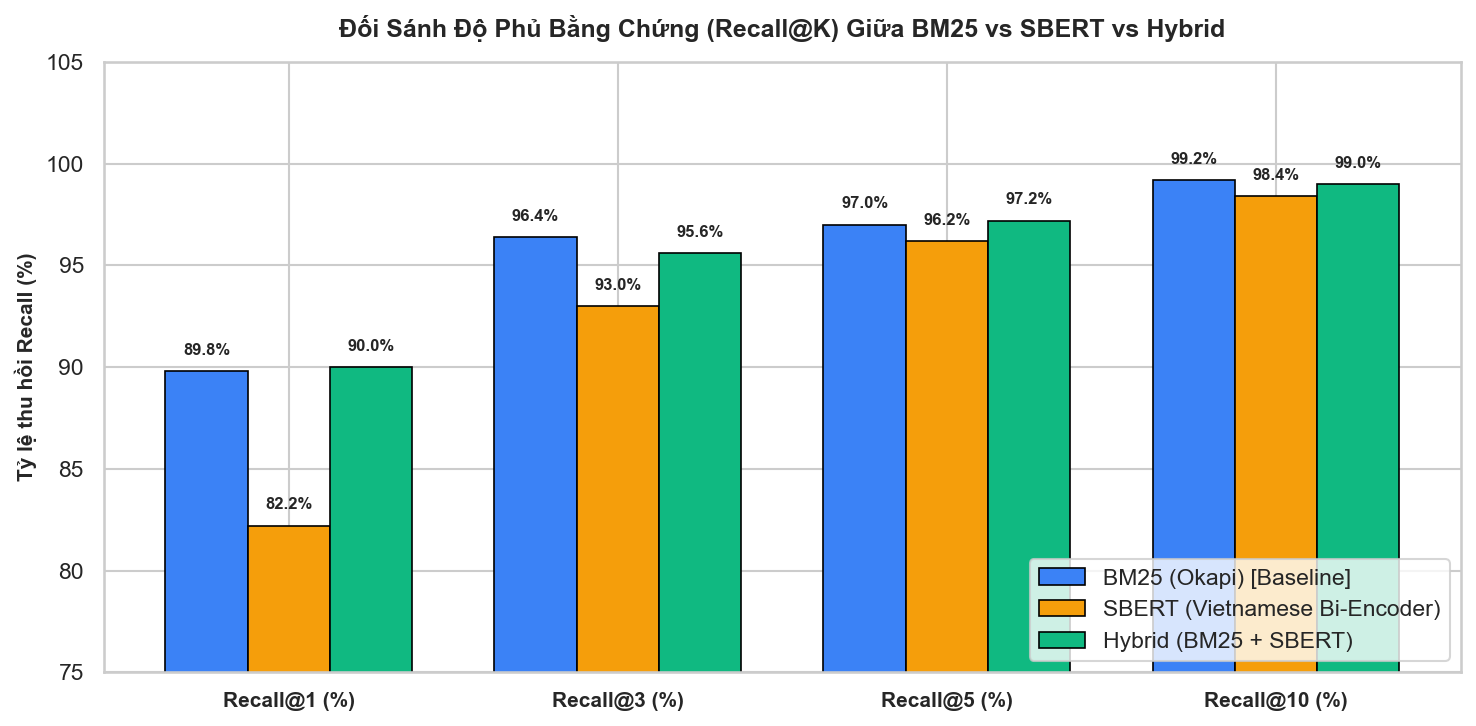

In [6]:
# Trực quan hóa đối sánh
plt.figure(figsize=(10, 5), dpi=150)
sns.set_theme(style="whitegrid")

metrics_to_plot = ["Recall@1 (%)", "Recall@3 (%)", "Recall@5 (%)", "Recall@10 (%)"]
methods = df_metrics["Phương pháp"].tolist()
x = np.arange(len(metrics_to_plot))
width = 0.25

colors = ["#3B82F6", "#F59E0B", "#10B981"]

for i, m_name in enumerate(methods):
    vals = df_metrics.loc[df_metrics["Phương pháp"] == m_name, metrics_to_plot].values[0]
    plt.bar(x + (i - 1) * width, vals, width, label=m_name, color=colors[i], edgecolor="black", linewidth=0.8)
    for j, v in enumerate(vals):
        plt.text(x[j] + (i - 1) * width, v + 0.8, f"{v:.1f}%", ha="center", fontsize=8, fontweight="bold")

plt.title("Đối Sánh Độ Phủ Bằng Chứng (Recall@K) Giữa BM25 vs SBERT vs Hybrid", fontsize=12, fontweight="bold", pad=12)
plt.ylabel("Tỷ lệ thu hồi Recall (%)", fontsize=10, fontweight="bold")
plt.xticks(x, metrics_to_plot, fontsize=10, fontweight="bold")
plt.ylim(75, 105)
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()

chart_path = METRICS_DIR / "08_stage1_ir_comparison.png"
plt.savefig(chart_path)
print(f"✓ Đã lưu biểu đồ đối sánh tại: {chart_path.name}")
plt.show()

## 7. Kết Nối Sang Bước 6 & Tổng Kết Hiệu Năng End-to-End

### Tác động của SBERT & Hybrid Search khi đưa vào Mô hình NLI (BamiBERT & PhoBERT):
Từ tập Top-10 ứng viên của Hybrid Search (`hybrid_top10_results.csv`), nhóm đã thực hiện đánh giá toàn diện tại **`06_end_to_end_retrieval_benchmark.ipynb`** với $K \in [1..5]$:
- **SBERT thuần túy:** Do tính chất làm mờ các thông tin số liệu và tên riêng trong vector dense, SBERT đơn lẻ cho F1 thấp hơn BM25 (~60% - 67% trên BamiBERT).
- **Hybrid Search (BM25 + SBERT):** Vượt trội ở $K=1$ (**61.95% F1**) và $K=3$ (**70.44% F1**), chứng minh việc kết hợp từ khóa bề mặt và ngữ nghĩa vector giúp giảm thiểu hiện tượng bỏ sót bằng chứng.
- **Hybrid + Fact-aware Rerank (Đề xuất):** Đưa hiệu năng tại điểm rơi $K^*=2$ lên đỉnh cao nhất toàn hệ thống: **72.03% Macro F1** (BamiBERT) và **65.67% Macro F1** (PhoBERT).

👉 *Xem chi tiết tại notebook:* [`06_end_to_end_retrieval_benchmark.ipynb`](./06_end_to_end_retrieval_benchmark.ipynb).